In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre
from mpmath import polylog
from scipy.optimize import minimize, root_scalar
from functools import lru_cache

In [23]:
# Parámetros iniciales
m_init = 92.72
g_init = 1.5
lamda = 0.85
mu = 1
T_v = np.linspace(50, 200, 1000)  
n2_puntos = 100  
n3_puntos = 100 
nodos2, pesos2 = roots_legendre(n2_puntos)
nodos3, pesos3 = roots_legendre(n3_puntos)


In [5]:
#Segundo derivada vectorizada
@lru_cache(maxsize=1000)
def cached_polylog(z):
    return float(polylog(2, z))

def PI(T_v, mu_q, g, lamda):
    T_v = np.asarray(T_v).item()
    exp_1 = -np.exp(mu_q / T_v)
    exp_2 = -np.exp(-mu_q / T_v)
    term_1 = (lamda * T_v**2) / 2
    t_2 = -((g**2 * T_v**2) / np.pi**2) * (cached_polylog(exp_1) + cached_polylog(exp_2))
    return term_1 + t_2

def D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos2) / (1 - nodos2)
    dk = 2 / (1 - nodos2)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = k_v**2 + Pi
    raiz = np.sqrt(arg + 0j)
    exp_arg_1 = np.exp(-(-mu_q + raiz) / T_v)
    numerador_1 = exp_arg_1 * g**2
    denominador_1 = 1 + exp_arg_1
    exp_arg_2 = np.exp(-(mu_q + raiz) / T_v)
    numerador_2 = exp_arg_2 * g**2
    denominador_2 = 1 + exp_arg_2
    Int_vals = (16 * T_v * lamda) * k_v**2 * (
        -numerador_1 / (denominador_1 * T_v * raiz)
        -numerador_2 / (denominador_2 * T_v * raiz)
    )
    return np.sum(dk * pesos2 * Int_vals)

def D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda):
    T_v = np.asarray(T_v).item()
    k_v = (1 + nodos3) / (1 - nodos3)
    dk = 2 / (1 - nodos3)**2
    Pi = PI(T_v, mu_q, g, lamda)
    arg = -m**2 + k_v**2 + Pi
    raiz = np.sqrt(arg + 0j)
    exp_arg = np.exp(-raiz / T_v)
    numerador = 3 * exp_arg * k_v**2 * lamda
    denominador = 1 - exp_arg
    Int_vals = (8 * T_v * lamda) * (numerador / (denominador * T_v * raiz))
    return np.sum(dk * pesos3 * Int_vals)

def Segunda_derivada(T_v, mu_q, lamda, m, g):
    term_1 = 1 / (16 * np.pi**2 * lamda)
    # Evitar problemas numéricos en los logaritmos
    mu_m_ratio = mu**2 / m**2
    if mu_m_ratio <= 0 or mu_m_ratio >= 2:  # Verificar dominio válido
        return np.inf
    term_2 = m**2 * (
        -4 * g**4 - 16 * np.pi**2 * lamda + 9 * lamda**2
        + 3 * lamda**2 * np.log(-mu_m_ratio + 0j)
        - 3 * lamda**2 * np.log(mu_m_ratio / 2)
    )
    term_3 = D2_Int_3(T_v, mu_q, nodos2, pesos2, m, g, lamda)
    term_4 = D2_Int_4(T_v, mu_q, nodos3, pesos3, m, g, lamda)
    return term_1 * (np.real(term_2) - term_3 + term_4)


In [7]:
#Enecuentra la raiz
def find_root(mu_q, T_v, lamda, m, g):
    def f(T):
        return np.real(Segunda_derivada(np.array([T]), mu_q, lamda, m, g))
    try:
        sol = root_scalar(f, bracket=[T_v[0], T_v[-1]], method='brentq')
        return sol.root if sol.converged else np.nan
    except ValueError:  # Manejar casos donde no hay cambio de signo
        return np.nan
        
#Encuentra la raiz para distintos valores de mu_q
def raiz(T_v, lamda, m, g):
    mu_q_values = np.arange(0, 101, 10)
    respuesta = [find_root(mu_q, T_v, lamda, m, g) for mu_q in mu_q_values]
    respuesta = np.array(respuesta)
    if np.isnan(respuesta[0]) or respuesta[0] == 0:  # Evitar división por cero
        return np.full_like(respuesta, np.nan)
    return respuesta

In [9]:
#Curva de TF de QCD y funcion de perdida
def Tf_QCD():
  Tc = []
  for i in range(11):
    x = (10*3*i)
    Tc.append(158 - 0.000096*(x**2) + 8.1129e-11*(x**4))# valores multiplicados por TC_0
  Tc = np.array(Tc)
  return Tc

def loss(parametros, mu_q_values=np.arange(0, 101, 10), lamda=1.3):
    m, g = parametros
    raiz_valores = raiz(T_v, lamda, m, g)
    if np.any(np.isnan(raiz_valores)):
        return 1e10
    raiz_QCD = Tf_QCD()
    return np.mean((raiz_valores - raiz_QCD)**2)

In [31]:
# Optimización
resultados = minimize(
    loss,
    x0=[100.793783, 2.373300],
    method='L-BFGS-B',
    bounds=[(50, 150), (0.5, 5)],
    options={'disp': True, 'maxiter': 100}
)
print("Parámetros óptimos encontrados (m, g):", resultados.x)

Parámetros óptimos encontrados (m, g): [101.24529971   2.49109029]


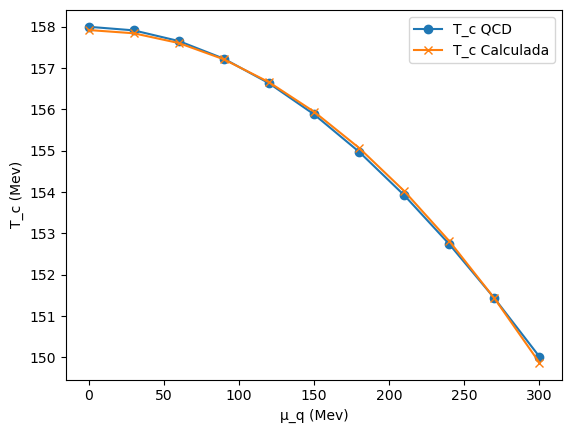

In [151]:
# Graficar resultados
m_opt, g_opt = resultados.x
Tc_opt = raiz(T_v, 0.85, m_opt, g_opt)
Tc_QCD = Tf_QCD()
plt.plot(np.arange(0, 301, 30), Tc_QCD, 'o-', label='T_c QCD')
plt.plot(np.arange(0, 301, 30), Tc_opt, 'x-', label='T_c Calculada')
plt.xlabel('μ_q (Mev)')
plt.ylabel('T_c (Mev)')
plt.legend()
plt.show()

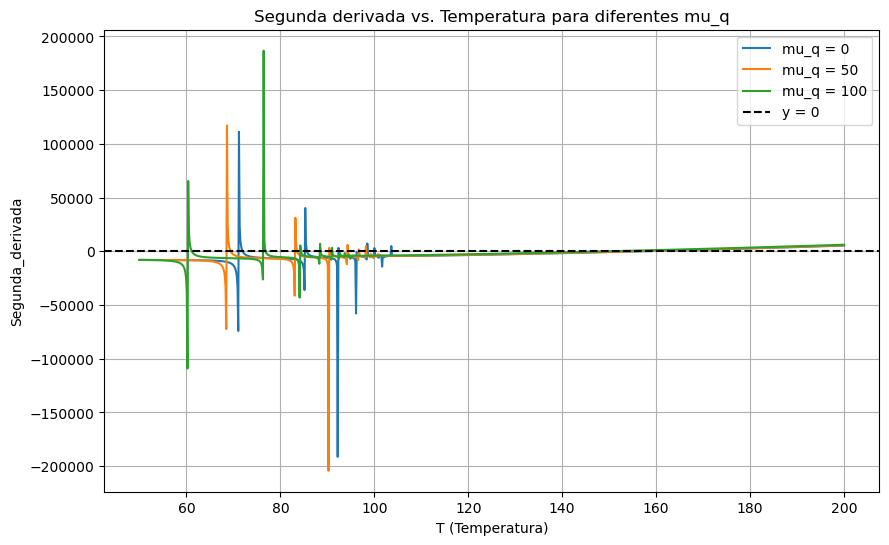

In [149]:
# Código para graficar Segunda_derivada (agregar después del código principal)

# Parámetros para el gráfico
mu_q_values = [0, 50, 100]  # Valores de mu_q para graficar
m = 92.72  # Valor inicial o usa m_opt después de la optimización
g = 1.5    # Valor inicial o usa g_opt después de la optimización
lamda = 0.85

# Crear figura
plt.figure(figsize=(10, 6))

# Evaluar y graficar para cada mu_q
for mu_q in mu_q_values:
    # Calcular Segunda_derivada para el rango de T_v
    d2v_values = np.array([np.real(Segunda_derivada(T, mu_q, lamda, m, g)) for T in T_v])
    
    # Filtrar valores no finitos (np.inf o np.nan) para evitar problemas en el gráfico
    mask = np.isfinite(d2v_values)
    T_v_filtered = T_v[mask]
    d2v_values_filtered = d2v_values[mask]
    
    # Graficar
    plt.plot(T_v_filtered, d2v_values_filtered, label=f'mu_q = {mu_q}')

# Línea horizontal en y = 0
plt.axhline(0, color='black', linestyle='--', label='y = 0')

# Configurar el gráfico
plt.xlabel('T (Temperatura)')
plt.ylabel('Segunda_derivada')
plt.title('Segunda derivada vs. Temperatura para diferentes mu_q')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
resultados.success




False

In [165]:
np.arange(0, 301, 30)

array([  0,  30,  60,  90, 120, 150, 180, 210, 240, 270, 300])

In [141]:
type(np.array([154]))

numpy.ndarray